# Koopman Autoencoder-Based Event Detection Using Moving Windows

This notebook implements a trajectory-based event detection workflow using a Koopman autoencoder (KAE). The example uses the synthetic three-tank system (TTS) dataset generated in the accompanying data-generation tutorial.

Unlike reconstruction-based approaches such as PCA and AE, which detect events using reconstruction errors, the KAE detects events using changes in the temporal evolution of a learned latent representation.

The KAE learns a nonlinear encoder-decoder pair together with an approximately linear latent-space evolution:

$$
z_{k+1} \approx A z_k
$$

where $z_k$ is the latent representation of the process measurement vector at time $t_k$, and $A$ is a learned Koopman operator. Event signatures are quantified using the latent dynamic increment:

$$
\Delta z_k \approx (A-I)z_k
$$

The sample-wise values of $\|(A-I)z_k\|$ are then aggregated over moving windows and mapped back to the original 4000-minute monitoring horizon.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers

## Load the Synthetic Three-Tank System Dataset

The dataset contains the measured liquid-level signals $h_1(t)$, $h_2(t)$, and $h_3(t)$, together with true states, inputs, flows, and fault labels. For KAE-based event detection, we use only the measured liquid-level variables as the multivariate monitoring data:

$$
\mathbf{x}(t) =
\begin{bmatrix}
h_1(t) & h_2(t) & h_3(t)
\end{bmatrix}^{T}
$$

The code below loads `TTS_multifault_short_events.csv`. Update `csv_path` if the dataset is stored in a different directory.

In [2]:
# Load data

csv_path = Path("../Example_Dataset/TTS_multifault_short_events.csv")

# If the CSV is in the same folder as this notebook, use:
# csv_path = Path("TTS_multifault_short_events.csv")

df = pd.read_csv(csv_path)

print(f"Loaded: {csv_path}")
print(df.head())

Loaded: TTS_multifault_short_events.csv
     t    q1_cmd    q3_cmd   h1_true   h2_true   h3_true   h1_meas   h2_meas  \
0  0.0  0.000022  0.000014  0.120000  0.100000  0.080000  0.119505  0.100718   
1  1.0  0.000022  0.000014  0.118991  0.099900  0.077705  0.118807  0.100908   
2  2.0  0.000022  0.000014  0.118033  0.099630  0.075610  0.118677  0.098973   
3  3.0  0.000022  0.000014  0.117114  0.099226  0.073687  0.117211  0.099146   
4  4.0  0.000022  0.000014  0.116224  0.098715  0.071911  0.116684  0.098793   

    h3_meas  q12_true  q23_true   q2_true  fault_active fault_type  fault_id  
0  0.080067  0.000038  0.000038  0.000088             0     normal        -1  
1  0.077018  0.000037  0.000040  0.000086             0     normal        -1  
2  0.075740  0.000036  0.000041  0.000085             0     normal        -1  
3  0.072973  0.000036  0.000042  0.000084             0     normal        -1  
4  0.072570  0.000035  0.000044  0.000083             0     normal        -1  


## Select Measured Variables and Normalize

We use the noisy measured variables as the monitoring signals:

$$
\mathbf{X} =
\begin{bmatrix}
\mathbf{x}(t_1)^T \\
\mathbf{x}(t_2)^T \\
\vdots \\
\mathbf{x}(t_M)^T
\end{bmatrix}
\in \mathbb{R}^{M \times n}
$$

where $M$ is the number of time samples and $n=3$ for this synthetic TTS example.

Each variable is normalized to $[0,1]$ so that the reconstruction error is not dominated by differences in variable scale.

In [3]:
# Variable Normalization

time_col = "t"
meas_cols = ["h1_meas", "h2_meas", "h3_meas"]

t = df[time_col].to_numpy(dtype=float)
X_raw = df[meas_cols].copy()

# Linear interpolation fills short NaN gaps; bfill/ffill handle edge cases
X_raw = X_raw.interpolate(method="linear", limit_direction="both")
X_raw = X_raw.bfill().ffill()

X = X_raw.to_numpy(dtype=float)

# Min-max normalization for each measured variable.
x_min = X.min(axis=0, keepdims=True)
x_max = X.max(axis=0, keepdims=True)
data_norm = (X - x_min) / (x_max - x_min + 1e-12)

print("Normalized data shape:", data_norm.shape)

Normalized data shape: (4001, 3)


## Construct Moving Windows for Trajectory-Based Monitoring

The KAE is applied on a moving-window basis. Each window is represented as:

$$
W_k = [\tau_k^s, \tau_k^e], \qquad k=1,\dots,K
$$

and the corresponding windowed data matrix is:

$$
\mathbf{X}_k \in \mathbb{R}^{M_k \times n}
$$

For this synthetic example, we use:

- window size = 60 samples,
- overlap = 10%.
- 
The representative time of each window is taken as the start time:

$$
\tau_k = \tau_k^s
$$

Unlike reconstruction-based approaches, the KAE is not trained using only a nominal region. Instead, all consecutive moving windows are used to learn the temporal evolution of the latent representation.

In [4]:
# Moving-window 

window_size = 60
overlap = 0.10
stride = int(round(window_size * (1.0 - overlap)))

if stride < 1:
    raise ValueError("Stride must be at least 1. Reduce overlap or increase window_size.")

start_indices = np.arange(0, len(data_norm) - window_size + 1, stride, dtype=int)
end_indices = start_indices + window_size

X_windows = np.stack(
    [data_norm[s:e, :] for s, e in zip(start_indices, end_indices)],
    axis=0
)

# Representative time for each window: start time of window
tau = t[start_indices]

print("Number of windows:", X_windows.shape[0])

Number of windows: 73


## Create Consecutive Window Pairs

The KAE learns the temporal evolution of the process in latent space. Therefore, the training pairs are constructed using consecutive moving windows:

$$
\mathbf{X}_k \rightarrow \mathbf{X}_{k+1}
$$

or equivalently in latent space:

$$
z_{k+1} \approx A z_k
$$

where $A$ is the learned Koopman operator.

Each window matrix $\mathbf{X}_k \in \mathbb{R}^{M_k \times n}$ is flattened into a single vector before being passed to the dense encoder-decoder networks.

In [5]:
# Create consecutive window pairs

K, Mk, n_features = X_windows.shape

# Flatten each window for dense KAE training
X_windows_flat = X_windows.reshape(K, -1).astype(np.float32)

# Consecutive window pairs: X_k -> X_{k+1}
xk_np = X_windows_flat[:-1]
xk1_np = X_windows_flat[1:]

N, state_dim = xk_np.shape

## Define the Koopman Autoencoder

The KAE consists of three components:

1. An encoder $E_{\theta}$ that maps each window to a latent state:

$$
z_k = E_{\theta}(\mathbf{X}_k)
$$

2. A decoder $D_{\phi}$ that reconstructs the window from the latent state:

$$
\widehat{\mathbf{X}}_k = D_{\phi}(z_k)
$$

3. A learned Koopman matrix $A$ that propagates the latent state forward by one window:

$$
z_{k+1} \approx A z_k
$$

The event-detection metric is later obtained from the latent dynamic increment:

$$
\Delta {\bf z}_k \approx {\bf (A-I)z}_k
$$

In [6]:
# Define Koopman Autoencoder model

np.random.seed(123)
tf.random.set_seed(123)

latent_dim = 2
hidden_dim = 8

class Encoder(tf.keras.Model):
    def __init__(self, state_dim, latent_dim, hidden_dim=4):
        super().__init__()
        self.d1 = layers.Dense(hidden_dim, activation="relu")
        self.out = layers.Dense(latent_dim, activation=None)

    def call(self, x):
        x = self.d1(x)
        return self.out(x)


class Decoder(tf.keras.Model):
    def __init__(self, latent_dim, state_dim, hidden_dim=4):
        super().__init__()
        self.d1 = layers.Dense(hidden_dim, activation="relu")
        self.out = layers.Dense(state_dim, activation=None)

    def call(self, z):
        z = self.d1(z)
        return self.out(z)


class KoopmanMatrix(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super().__init__()
        self.A = self.add_weight(
            shape=(latent_dim, latent_dim),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
            trainable=True,
            name="A"
        )

    def call(self):
        return self.A


enc = Encoder(state_dim, latent_dim, hidden_dim=hidden_dim)
dec = Decoder(latent_dim, state_dim, hidden_dim=hidden_dim)
A_layer = KoopmanMatrix(latent_dim)

A = A_layer.A

## Train the Koopman Autoencoder on All Consecutive Windows

The KAE is trained using all consecutive moving-window pairs. The training objective contains a reconstruction term and a latent dynamics term:

$$
\mathcal{L}
=
\mathcal{L}_{rec}
+
\lambda_{dyn}\mathcal{L}_{dyn}
$$

where:

$$
\mathcal{L}_{rec}
=
\left\|
\mathbf{X}_k - D_{\phi}(E_{\theta}(\mathbf{X}_k))
\right\|^2
$$

and:

$$
\mathcal{L}_{dyn}
=
\left\|
E_{\theta}(\mathbf{X}_{k+1}) - A E_{\theta}(\mathbf{X}_k)
\right\|^2
$$

This is different from PCA and AE monitoring, where the model is trained only on nominal operation data. Here, the goal is to learn the temporal evolution of the latent trajectory across the full monitoring horizon.

In [7]:
# Train Koopman Autoencoder 

batch_size = 16
epochs = 200
learning_rate = 5e-4
lambda_dyn = 1.0

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

for epoch in range(1, epochs + 1):

    idx_perm = np.random.permutation(N)

    total_loss = 0.0
    total_rec = 0.0
    total_dyn = 0.0
    n_batches = 0

    for start in range(0, N, batch_size):
        batch_idx = idx_perm[start:start + batch_size]

        xk_b  = tf.convert_to_tensor(xk_np[batch_idx], dtype=tf.float32)
        xk1_b = tf.convert_to_tensor(xk1_np[batch_idx], dtype=tf.float32)

        with tf.GradientTape() as tape:

            # Encode current and next windows
            z   = enc(xk_b)
            z1  = enc(xk1_b)

            # Koopman latent prediction: z_{k+1} = A z_k
            z1_pred = tf.linalg.matmul(z, tf.transpose(A))

            # Reconstruction of current window
            x_rec = dec(z)

            # Losses
            loss_rec = tf.reduce_mean(tf.square(xk_b - x_rec))
            loss_dyn = tf.reduce_mean(tf.square(z1 - z1_pred))
            loss = loss_rec + lambda_dyn * loss_dyn

        vars_all = enc.trainable_variables + dec.trainable_variables + [A]
        grads = tape.gradient(loss, vars_all)
        optimizer.apply_gradients(zip(grads, vars_all))

        total_loss += float(loss)
        total_rec += float(loss_rec)
        total_dyn += float(loss_dyn)
        n_batches += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"total={total_loss / n_batches:.6f} | "
            f"rec={total_rec / n_batches:.6f} | "
            f"dyn={total_dyn / n_batches:.6f}"
        )

Epoch   1 | total=0.099247 | rec=0.061430 | dyn=0.037817
Epoch  10 | total=0.050095 | rec=0.049319 | dyn=0.000777
Epoch  20 | total=0.036951 | rec=0.036159 | dyn=0.000792
Epoch  30 | total=0.023169 | rec=0.021583 | dyn=0.001586
Epoch  40 | total=0.013624 | rec=0.012184 | dyn=0.001440
Epoch  50 | total=0.009781 | rec=0.008812 | dyn=0.000969
Epoch  60 | total=0.008360 | rec=0.007558 | dyn=0.000801
Epoch  70 | total=0.007320 | rec=0.006546 | dyn=0.000774
Epoch  80 | total=0.006460 | rec=0.005365 | dyn=0.001094
Epoch  90 | total=0.006421 | rec=0.004921 | dyn=0.001501
Epoch 100 | total=0.004455 | rec=0.002900 | dyn=0.001555
Epoch 110 | total=0.003996 | rec=0.002321 | dyn=0.001675
Epoch 120 | total=0.003646 | rec=0.002093 | dyn=0.001553
Epoch 130 | total=0.003166 | rec=0.001773 | dyn=0.001393
Epoch 140 | total=0.002880 | rec=0.001595 | dyn=0.001285
Epoch 150 | total=0.002567 | rec=0.001425 | dyn=0.001143
Epoch 160 | total=0.002603 | rec=0.001344 | dyn=0.001259
Epoch 170 | total=0.002328 | re

## Compute the KAE Latent Dynamics Metric

After training, each moving window is encoded into latent space:

$$
z_k = E_{\theta}(\mathbf{X}_k)
$$

The KAE monitoring signal is computed as:

$$
s_k = {\bf \left\|(A-I)z_k\right\|}
$$

where $I$ is the identity matrix. Large values of $s_k$ indicate abrupt movement in the learned latent trajectory and are interpreted as event signatures.

In [8]:
# Compute window-wise KAE latent dynamics metric

X_windows_tf = tf.convert_to_tensor(X_windows_flat, dtype=tf.float32)

Z = enc(X_windows_tf)
Z = tf.convert_to_tensor(Z, dtype=tf.float32)

I = tf.eye(latent_dim, dtype=tf.float32)
A_minus_I = A - I

dz_pred = tf.linalg.matmul(Z, A_minus_I, transpose_b=True)
s_window = tf.norm(dz_pred, axis=1).numpy()

## Optional Smoothing

A light exponential moving average (EMA) is used to smooth the window-wise latent-dynamics profile for visualization:

$$
\bar{s}_k
=
\alpha s_k
+
(1-\alpha)\bar{s}_{k-1}
$$

In [9]:
# Optional smoothing

def ema(x, alpha=0.60):
    y = np.empty_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1.0 - alpha) * y[i - 1]
    return y

s_window_plot = ema(s_window, alpha=0.90)

## Plot KAE-Based Event Detection Results

The KAE latent-dynamics metric is plotted against the representative time $\tau_k$, which maps the window-scale result back to the original physical time axis of the process.

For this synthetic TTS dataset, the monitoring horizon is approximately 4000 minutes.

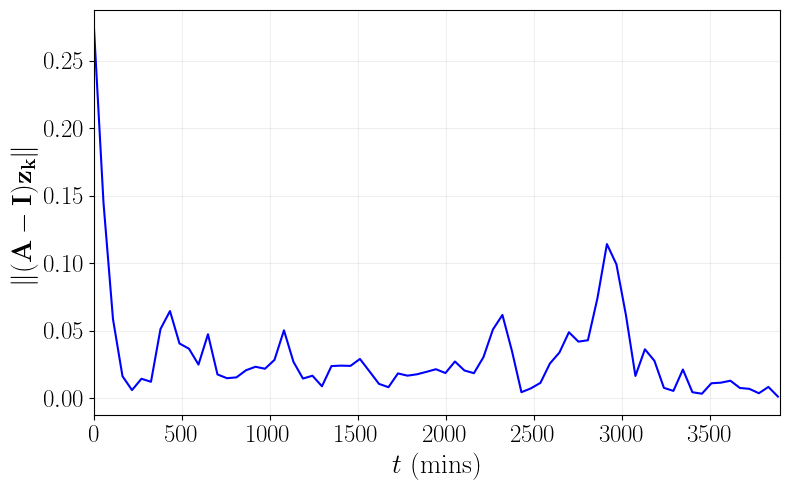

In [10]:
# Plot KAE latent dynamics metric

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.titlesize": 22,
    "legend.fontsize": 14,
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    tau,
    s_window_plot,
    color="blue",
    lw=1.5
)

ax.set_xlabel(r"$t$ (mins)")
ax.set_ylabel(r"$\bf \|(A-I)z_k\|$")
ax.set_xlim(0, 3900)
ax.grid(True, alpha=0.20)

plt.tight_layout()
plt.show()